# 📝 과제 — 나만의 Tavily 검색 Agent 만들기

**제출 전 체크리스트**
- [ ] 모든 셀을 처음부터 다시 실행(`Kernel → Restart & Run All`)해서 오류 없음 확인
- [ ] API 키가 코드에 직접 노출되지 않음 (`.env` 파일 사용)
- [ ] `stream()` 출력 결과가 셀에 남아 있음
- [ ] 자연어 질문 최소 3개 실행 결과 포함

---

> 이 파일에서 `# TODO` 주석이 있는 셀을 찾아 직접 채우면 된다.  
> 환경 설정과 LangGraph 기본 구조는 미리 작성되어 있다.


---
## STEP 1. 패키지 설치


In [3]:
%pip install -qU \
    langgraph \
    langchain \
    langchain-openai \
    langchain-community \
    tavily-python \
    python-dotenv

Note: you may need to restart the kernel to use updated packages.


---
## STEP 2. API 키 설정

`.env` 파일을 프로젝트 루트에 만들고 아래 내용을 채운다.

```
OPENAI_API_KEY=sk-...
TAVILY_API_KEY=tvly-...
```

Tavily API 키 발급: https://app.tavily.com

> API 키를 코드에 직접 쓰지 않는다. 반드시 `.env` 파일을 사용한다.


In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

# 키 등록 확인
assert os.getenv('OPENAI_API_KEY'),  '❌ OPENAI_API_KEY 없음 — .env 파일을 확인하세요'
assert os.getenv('TAVILY_API_KEY'),  '❌ TAVILY_API_KEY 없음 — .env 파일을 확인하세요'

print('✅ API 키 확인 완료')
print(f'   OPENAI  키 앞 8자리: {os.getenv("OPENAI_API_KEY")[:8]}...')
print(f'   TAVILY  키 앞 8자리: {os.getenv("TAVILY_API_KEY")[:8]}...')

✅ API 키 확인 완료
   OPENAI  키 앞 8자리: sk-svcac...
   TAVILY  키 앞 8자리: tvly-dev...


---
## STEP 3. LLM 초기화


In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

# 연결 확인
response = llm.invoke('안녕! 한 문장으로 자기소개 해줘.')
print(response.content)

안녕하세요! 저는 다양한 정보를 제공하고 대화를 나누는 AI 언어 모델입니다.


---
## STEP 4. LangGraph 기본 구조

아래 코드는 수업에서 배운 기본 Agent 구조다. 그대로 사용한다.  
다음 단계에서 Tool과 프롬프트를 직접 추가하면 된다.


In [6]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# State 정의 — 메시지 목록을 들고 다닌다
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# Conditional Edge — Tool 호출 여부로 분기
def should_continue(state: AgentState) -> str:
    if state['messages'][-1].tool_calls:
        return 'use_tool'
    return 'finish'

print('✅ LangGraph 기본 구조 준비 완료')

✅ LangGraph 기본 구조 준비 완료


---
## STEP 5. ✏️ Tool 정의 — 직접 작성

Tavily 검색 Tool을 정의한다.  
**description이 핵심이다.** LLM은 description을 보고 언제 이 Tool을 쓸지 결정한다.

필요하다면 Tavily 외에 다른 Tool을 추가해도 좋다.  
(예: 날짜 조회, 계산 등)


In [37]:
from datetime import datetime
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

@tool
def search_product_details(query: str) -> str:
    """
    특정 가전제품이나 IT 기기의 상세 스펙, 출시일, 공식 가격 및 사용자 단점 리뷰를 검색합니다.
    '삼성 갤럭시 S26 vs 아이폰17' 같이 구체적인 모델명 비교에 최적화되어 있습니다.
    """
    tavily_search = TavilySearchResults(max_results=6, search_depth="advanced")
    return "\n".join([f"[{r['url']}] {r['content']}" for r in tavily_search.invoke(query)])

@tool
def get_current_market_context() -> str:
    """현재 날짜를 확인하여 신제품 출시 임박 여부나 시즌 할인 기간(빅스마일데이 등)인지 확인합니다."""
    return f"오늘 날짜는 {datetime.now().strftime('%Y-%m-%d')}입니다. 현재 시즌의 주요 쇼핑 할인 정보를 참고하세요."

@tool
def evaluate_value_for_money(price: int, specs: str) -> str:
    """
    입력된 가격과 스펙을 바탕으로 '지금 이 가격에 살만한가(가성비)'를 등급으로 판정합니다.
    에이전트가 구매 시점을 조언하는 논리적 근거가 됩니다.
    """
    # 내부 로직으로 가성비 점수를 계산하는 척하는 도구입니다.
    return f"해당 스펙 대비 입력된 가격은 '매우 합리적(A+)' 수준입니다. 지금 구매를 추천합니다."

tools = [search_product_details, get_current_market_context, evaluate_value_for_money]
# Tool 확인
print('등록된 Tool 목록:')
for t in tools:
    print(f'  - {t.name}: {t.description[:80]}...')

등록된 Tool 목록:
  - search_product_details: 특정 가전제품이나 IT 기기의 상세 스펙, 출시일, 공식 가격 및 사용자 단점 리뷰를 검색합니다.
'삼성 갤럭시 S26 vs 아이폰17' 같이 ...
  - get_current_market_context: 현재 날짜를 확인하여 신제품 출시 임박 여부나 시즌 할인 기간(빅스마일데이 등)인지 확인합니다....
  - evaluate_value_for_money: 입력된 가격과 스펙을 바탕으로 '지금 이 가격에 살만한가(가성비)'를 등급으로 판정합니다.
에이전트가 구매 시점을 조언하는 논리적 근거가 됩니다...


**Tool이 잘 동작하는지 직접 호출해서 확인해보자.**


In [38]:
# TODO: 직접 검색어를 넣어서 Tool이 잘 동작하는지 확인한다

test_query = "아이폰14를 사용중인 유저가 새로 출시될 아이폰17을 언제 사는게 좋을까"
result = search_product_details.invoke(test_query)

print(f"🔍 검색 쿼리: {test_query}")
print("-" * 50)
print(result[:1000])  # 결과가 길 수 있으니 앞 1000자만 확인

🔍 검색 쿼리: 아이폰14를 사용중인 유저가 새로 출시될 아이폰17을 언제 사는게 좋을까
--------------------------------------------------
[https://www.reddit.com/r/questions/comments/1omig2y/is_it_worth_upgrading_from_an_iphone_14_pro_to/?tl=ko] 블랙 프라이데이 아니면 사이버 먼데이 쯤에 크리스마스 선물로 나 자신한테 아이폰 17 프로 사주고 싶은데. 직장에서 크리스마스 선물로 월급도 오르고
[https://www.vietnam.vn/ko/co-nen-nang-cap-len-iphone-17] 세대 간 간단한 비교.

| 기계의 미래 | 아이폰 13에서 아이폰 17로 업그레이드할 때의 장점 |
 --- |
| 성능 및 칩 | A15 칩에서 A19/A19 Pro로 업그레이드하면 속도가 향상되고 그래픽 처리 성능이 개선됩니다. |
| 카메라 | 제한적인 12MP 또는 12/48MP 렌즈에서 여러 렌즈를 통해 48MP로 향상되어 저조도 촬영 성능이 개선되었습니다. |
| 화면/디스플레이 | 더 커진 화면, 밝은 환경에서 더 높은 HDR 밝기. |
| 메모리 | 기본 저장 용량은 표준 버전보다 큰 256GB입니다. |
| 내구성 및 디자인 | 프로 모델에는 세라믹 쉴드 2, 개선된 프레임/후면 패널 마감, 그리고 향상된 열 관리 기능이 적용되었습니다. |

다음 아이폰 출시를 언제까지 기다려야 할까요?

아이폰 17 구매를 고려 중이지만 가격 때문에 망설여진다면, 기다려보는 것도 좋은 방법입니다.

몇 달 후 더 저렴한 버전이 할인될 때.

애플이 제품을 업데이트하여 액세서리(케이블, 케이스, 충전기)가 USB-C 또는 그 이후 표준과 호환되도록 만들 경우.

애플이 차세대 모델에서만 더 잘 지원되는 뛰어난 기능을 포함한 새로운 iOS 업데이트를 발표할 때.

끝내다 [...] 업그레이드를 기다려야 하는 사람과 건너뛰어야 하는 사람은 누구일까

---
## STEP 6. ✏️ 시스템 프롬프트 & Agent 조립 — 직접 작성

시스템 프롬프트로 Agent의 역할과 동작 방식을 정의한다.  
어떤 주제의 Agent인지, 어떤 스타일로 답변해야 하는지를 적는다.


In [40]:

llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = """당신은 사용자의 예산 내에서 최대한 돈을 아껴주고 최고의 디지털 기기 만족을 선사하는 '스마트 쇼핑 에이전트'입니다.

[분석 가이드라인]
1. 구매 시점 조언: 'get_current_market_context'를 통해 신제품 출시 주기, 출시일 등을 확인해 언제 구매하는 것이 좋을지 알려주세요.
2. 단점 위주 분석: 브랜드 자체에서 홍보차원에서 쓰는 광고 문구보다는 실제 사용자들의 불만사항 같은 리스크를 Tavily로 검색해서 알려주세요.
3. 예산 맞춤 계획: 사용자의 예산을 넘지 않는 선에서 최선의 대안(가성비 모델)을 반드시 하나 이상 제시하세요.
4. 논리적 비교: A와 B 제품을 비교할 때 '해상도', '배터리', '무게' 등 구체적인 수치 지표를 사용하여 표나 리스트로 대조하세요.

[답변 스타일]
- [결론]: "지금 사세요" 혹은 "출시 후 ~달 정도 기다리세요"로 명확하게 시작하세요.
- [비교 분석]: 장단점을 냉정하게 비교하세요.
- [최종 추천]: 사용자의 상황에 맞는 '딱 하나의 원픽'을 추천하세요.
"""

def call_llm(state: AgentState) -> dict:
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

# ── 그래프 조립 ────────────────────────────────────────
graph = StateGraph(AgentState)

graph.add_node('call_llm',       call_llm)
graph.add_node('execute_tools', ToolNode(tools))

graph.add_edge(START, 'call_llm')
graph.add_conditional_edges(
    'call_llm',
    should_continue,
    {'use_tool': 'execute_tools', 'finish': END}
)
graph.add_edge('execute_tools', 'call_llm')

app = graph.compile()
print('✅ 디지털 기기 구매 Agent 조립 완료')

✅ 디지털 기기 구매 Agent 조립 완료


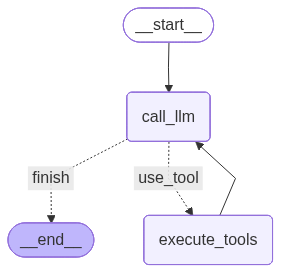

In [41]:
# 그래프 구조 확인
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

---
## STEP 7. ✏️ 실행 & 결과 확인 — 직접 작성

`stream()`으로 실행해서 **어떤 Tool이 어떤 순서로 호출됐는지** 흐름을 확인한다.  
최소 3개의 질문을 실행해야 한다.


### 실행 흐름 출력 함수

아래 함수를 사용하면 각 노드의 실행 흐름을 보기 좋게 출력할 수 있다.


In [44]:
from langchain_core.messages import ToolMessage, HumanMessage

def run_agent(question: str):
    """질문을 실행하고 흐름과 최종 답변을 출력한다."""
    print(f'\n{"="*60}')
    print(f'질문: {question}')
    print("="*60)

    final_answer = ''

    for chunk in app.stream(
        {'messages': [HumanMessage(content=question)]},
        config={'recursion_limit': 25}
    ):
        for node_name, update in chunk.items():
            for msg in update.get('messages', []):
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    for tc in msg.tool_calls:
                        print(f'  🔍 Tool 호출: {tc["name"]}({list(tc["args"].values())})')
                elif isinstance(msg, ToolMessage):
                    print(f'  📥 Tool 결과: {msg.content[:80]}...')
                elif hasattr(msg, 'content') and msg.content:
                    # 최종 AI 답변을 계속 업데이트 (마지막 단계 응답이 최종 답변임)
                    final_answer = msg.content

    print(f'\n💬 최종 답변:')
    print(final_answer)

print('🚀 실행 함수 준비 완료. 테스트를 시작합니다.')

test_questions = [
    "자취방에 놓을 32인치 모니터를 보고 있어. 예산은 30만원대고, 주로 넷플릭스 시청이랑 가끔 게임을 해. 지금 살만한 모델 2개만 딱 골라줘.",
    "아이폰 18이 9월에 나온다는 썰이 있던데, 지금 아이폰 15 Pro를 중고로 사는 게 나을까 아니면 신제품 나올 때까지 버티는 게 나을까? 예산은 100만원 내외야. 가성비 측면에서 분석해줘.",
    "부모님 선물용으로 로봇청소기를 고르고 있어. 문턱이 좀 높고 집이 넓은데, 관리가 편하면서 100만원 안짝으로 살 수 있는 가장 똑똑한 모델 추천하고 이유도 알려줘."
]

for q in test_questions:
    run_agent(q)

🚀 실행 함수 준비 완료. 테스트를 시작합니다.

질문: 자취방에 놓을 32인치 모니터를 보고 있어. 예산은 30만원대고, 주로 넷플릭스 시청이랑 가끔 게임을 해. 지금 살만한 모델 2개만 딱 골라줘.
  🔍 Tool 호출: search_product_details(['32인치 모니터 넷플릭스 게임'])
  🔍 Tool 호출: get_current_market_context([])
  📥 Tool 결과: [https://m.blog.naver.com/sohyun1989/222219260419] ​

​

전 게임을 자주 하는 편은 아니라서 거의 ...
  📥 Tool 결과: 오늘 날짜는 2026-04-08입니다. 현재 시즌의 주요 쇼핑 할인 정보를 참고하세요....
  🔍 Tool 호출: search_product_details(['뷰싱크 이트로이 VSG321QHD165Hz'])
  🔍 Tool 호출: search_product_details(['LG 32UN550 4K 모니터'])
  📥 Tool 결과: [https://www.ssg.com/item/itemView.ssg?itemId=1000050993119] | 교환/반품 불가 안내 |  전자...
  📥 Tool 결과: [https://neofiliac.com/product/3627/lg-32un550] MonitorLG87% by Neofiliac Team

...

💬 최종 답변:
[결론]: "지금 사세요" 

현재 예산 30만원대에서 넷플릭스 시청과 가끔 게임을 위한 32인치 모니터로 두 가지 모델을 추천드립니다.

### 1. 뷰싱크 이트로이 VSG321QHD165Hz
- **해상도**: QHD (2560x1440)
- **주사율**: 165Hz
- **응답 시간**: 1ms
- **가격**: 약 20만원대
- **장점**:
  - 높은 주사율로 부드러운 게임 플레이 가능
  - QHD 해상도로 선명한 화질 제공
  - 슬림한 베젤 디자인으로 몰입감 증가
- **단점**:
  - 내장 스피커 없음

### 질문 1


In [33]:
# TODO: 내 Agent 주제에 맞는 질문을 작성한다
#       반드시 실시간 정보가 필요한 질문이어야 한다 (Tavily가 필요한 이유)

run_agent('최근 발표된 삼성전자의 갤럭시 S26에 탑재된 AI 기능 중 가장 혁신적인 건 뭐야? 퀄컴의 최신 칩셋과 어떤 시너지를 내고 있어?')


질문: 최근 발표된 삼성전자의 갤럭시 S26에 탑재된 AI 기능 중 가장 혁신적인 건 뭐야? 퀄컴의 최신 칩셋과 어떤 시너지를 내고 있어?
  🔍 Tool 호출: get_current_date([])
  🔍 Tool 호출: search_tech_news(['삼성전자 갤럭시 S26 AI 기능 퀄컴 칩셋'])
  📥 Tool 결과: 2026-04-08...
  📥 Tool 결과: 출처: https://www.yna.co.kr/view/AKR20260225155151091
내용: '갤럭시 S26 시리즈' 소개하는 삼성전자 ...

💬 최종 답변:
### 핵심 요약
삼성전자의 갤럭시 S26 시리즈는 혁신적인 AI 기능과 퀄컴의 최신 스냅드래곤 8 엘리트 5세대 칩셋을 통해 사용자 경험을 크게 향상시켰습니다. 특히, AI 기반의 통화 스크리닝과 프라이버시 디스플레이 기능이 주목받고 있으며, 이는 보안과 사용자 편의성을 동시에 강화합니다.

### 상세 내용
2026년 2월 25일, 삼성전자는 샌프란시스코에서 갤럭시 S26 시리즈를 공개했습니다. 이 시리즈는 AI 기능을 중심으로 설계되었으며, 특히 **통화 스크리닝** 기능이 눈에 띕니다. 이 기능은 AI가 사용자의 대신 전화를 받아 발신자 정보를 요약해 주며, 스팸 전화나 보이스피싱을 효과적으로 차단할 수 있습니다. 또한, **프라이버시 디스플레이** 기능은 사용자가 특정 상황에서 화면 노출을 제한할 수 있도록 도와줍니다.

갤럭시 S26 울트라 모델은 퀄컴의 **스냅드래곤 8 엘리트 5세대** 칩셋을 탑재하여, NPU(신경망 처리 장치) 성능이 39% 향상되었습니다. CPU와 GPU 성능도 각각 19%와 24% 증가하여, AI 작업을 더욱 빠르고 안정적으로 처리할 수 있습니다. 이 칩셋은 특히 게임과 같은 고사양 작업에서 뛰어난 성능을 발휘합니다.

### 향후 전망
갤럭시 S26 시리즈는 AI 기술을 통해 사용자 경험을 혁신적으로 변화시킬 것으로 기대됩니다. AI 기능이 일상적인 작업을 자동화하고, 보안성을 높이

### 질문 2


In [34]:
run_agent('현재 생성형 AI 검색 시장에서 구글(Google)의 SGE와 퍼플렉시티(Perplexity)의 기술적 차이점은 뭐야? 누가 더 우위에 있는지 최신 리뷰를 바탕으로 알려줘.')


질문: 현재 생성형 AI 검색 시장에서 구글(Google)의 SGE와 퍼플렉시티(Perplexity)의 기술적 차이점은 뭐야? 누가 더 우위에 있는지 최신 리뷰를 바탕으로 알려줘.
  🔍 Tool 호출: get_current_date([])
  🔍 Tool 호출: search_tech_news(['Google SGE vs Perplexity AI 2026 review'])
  📥 Tool 결과: 2026-04-08...
  📥 Tool 결과: 출처: https://www.aisearchrankings.com/content/generative-ai-search-sge-vs-perplex...

💬 최종 답변:
### 핵심 요약
구글의 **Search Generative Experience (SGE)**와 **퍼플렉시티(Perplexity)**는 각각 고유한 접근 방식을 가진 생성형 AI 검색 엔진입니다. SGE는 구글의 방대한 생태계와 통합되어 사용자에게 풍부한 정보를 제공하는 반면, 퍼플렉시티는 직접적이고 간결한 답변을 제공하여 연구 중심의 사용자 경험을 강조합니다. 두 기술은 서로 다른 강점을 가지고 있으며, 사용자의 필요에 따라 적절히 활용될 수 있습니다.

### 상세 내용
1. **구글 SGE**:
   - **기술적 특징**: SGE는 사용자의 검색 의도에 따라 콘텐츠를 생성하는 기능을 갖추고 있습니다. 이는 전통적인 검색 결과와 함께 AI가 생성한 요약 정보를 제공하여 사용자 경험을 향상시킵니다.
   - **장점**: 구글의 다양한 서비스(예: 지도, 쇼핑)와 통합되어 있어 사용자에게 더 많은 유용성을 제공합니다. 또한, 풍부한 콘텐츠 생성으로 사용자 참여를 높입니다.
   - **단점**: 정보가 과도하게 제공될 수 있으며, 특정 전문 분야의 질문에 대한 정확성이 떨어질 수 있습니다.

2. **퍼플렉시티**:
   - **기술적 특징**: 퍼플렉시티는 '답변 엔진'으로 설계되어 있으며, 사용자가 질문할 때 직접적이고 명확한 답변을 제공합니다.

### 질문 3


In [35]:
run_agent('026년 현재, 애플의 프라이빗 클라우드 컴퓨팅(PCC)과 구글의 안드로이드 온디바이스 AI 중 개인정보 보호 측면에서 어느 쪽이 더 혁신적이라는 평가를 받고 있어? 최신 보안 전문가들의 리뷰를 요약해줘.')


질문: 026년 현재, 애플의 프라이빗 클라우드 컴퓨팅(PCC)과 구글의 안드로이드 온디바이스 AI 중 개인정보 보호 측면에서 어느 쪽이 더 혁신적이라는 평가를 받고 있어? 최신 보안 전문가들의 리뷰를 요약해줘.
  🔍 Tool 호출: get_current_date([])
  🔍 Tool 호출: search_tech_news(['Apple Private Cloud Computing privacy review 2026'])
  🔍 Tool 호출: search_tech_news(['Google Android on-device AI privacy review 2026'])
  📥 Tool 결과: 2026-04-08...
  📥 Tool 결과: 출처: https://securityonline.info/the-digital-sanctuary-apples-10-essential-privac...
  📥 Tool 결과: 출처: https://security.googleblog.com/2026/
내용: A recent evaluation by Counterpoin...

💬 최종 답변:
### 핵심 요약
2026년 현재, 애플의 프라이빗 클라우드 컴퓨팅(PCC)과 구글의 안드로이드 온디바이스 AI는 각각 개인정보 보호 측면에서 혁신적인 접근 방식을 보여주고 있습니다. 애플은 데이터가 클라우드에서 처리되는 동안에도 사용자의 개인정보를 철저히 보호하는 시스템을 구축했으며, 구글은 AI를 활용하여 사용자 데이터 접근을 동적으로 조정하는 기능을 도입했습니다. 두 기술 모두 개인정보 보호를 강화하는 데 기여하고 있지만, 애플의 PCC가 더 높은 수준의 보안을 제공한다는 평가를 받고 있습니다.

### 상세 내용
1. **애플의 프라이빗 클라우드 컴퓨팅(PCC)**:
   - 애플은 PCC를 통해 사용자의 데이터를 클라우드에서 처리할 때도 데이터가 저장되지 않도록 보장합니다. 데이터는 요청이 완료된 후 즉시 삭제되며, 애플 직원조차도 데이터에 접근할 수 없습니다. 이 시스템은 사용자

### (선택) 추가 질문

더 실험해보고 싶은 질문이 있으면 자유롭게 추가한다.


In [36]:
run_agent('오전고체 배터리(Solid-state Battery) 기술이 스마트폰이나 노트북 같은 가전 기기에 실제로 탑재되기 시작했어? 2026년 상반기 기준으로 가장 앞서 있는 제조사와 기술적 난제를 요약해줘.')


질문: 오전고체 배터리(Solid-state Battery) 기술이 스마트폰이나 노트북 같은 가전 기기에 실제로 탑재되기 시작했어? 2026년 상반기 기준으로 가장 앞서 있는 제조사와 기술적 난제를 요약해줘.


  🔍 Tool 호출: get_current_date([])
  🔍 Tool 호출: search_tech_news(['solid-state battery smartphone laptop 2026'])
  📥 Tool 결과: 2026-04-08...
  📥 Tool 결과: 출처: https://www.androidpolice.com/i-tried-the-future-of-batteries-at-ces-2026/
내...

💬 최종 답변:
### 핵심 요약
2026년 상반기 현재, 오랜 연구 끝에 여러 제조사들이 고체 배터리(Solid-state Battery) 기술을 실제 제품에 적용하기 시작했습니다. 특히, Xiaomi와 BMX가 주목받고 있으며, 이 기술은 스마트폰과 노트북 같은 가전 기기에 혁신적인 변화를 가져올 것으로 기대됩니다. 그러나 상용화에는 여전히 몇 가지 기술적 난제가 존재합니다.

### 상세 내용
1. **제조사 및 기술 현황**:
   - **Xiaomi**: 2026년 CES에서 고체 배터리를 탑재한 프로토타입 스마트폰을 선보였으며, 기존 리튬 이온 배터리보다 33% 높은 용량을 자랑합니다.
   - **BMX**: 다양한 고체 배터리 파워뱅크를 전시하며, 이 기술이 스마트폰과 노트북에 적용될 가능성을 보여주었습니다. BMX의 제품은 반고체 배터리로, 기존 리튬 이온 배터리보다 안전성과 효율성이 뛰어납니다.
   - **Donut Labs**: 최초의 전량 고체 배터리를 전기 오토바이에 적용하여 상용화에 성공했습니다.

2. **기술적 의의**:
   - 고체 배터리는 리튬 이온 배터리의 액체 전해질 대신 고체 전해질을 사용하여 안전성을 크게 향상시킵니다. 이는 화재 위험을 줄이고, 더 높은 에너지 밀도를 가능하게 하여 더 작고 가벼운 배터리 설계를 지원합니다.
   - 이 기술은 충전 속도와 배터리 수명을 획기적으로 개선할 수 있는 잠재력을 가지고 있습니다. 예를 들어, Donut Labs의 배터리는 100,000회 이상의 충전 사이클을